<a href="https://colab.research.google.com/github/angioitoan2409/flood_forecasting/blob/main/data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install libraries

In [2]:
!pip install rasterio geopandas -q

##Imports + configuration

In [3]:
import os
import glob
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.features import rasterize
import geopandas as gpd

# ---- EDIT THESE PATHS to match your Google Drive layout ----
DEM_TILES_GLOB = "/content/drive/MyDrive/flood_forecasting/data/dem/dgm1_*.tif"   # all 16 tiles
SEALING_SHP = "/content/drive/MyDrive/flood_forecasting/data/sealing/BODENVERSIEGELUNG_GITTER100M.shp"
BUILDINGS_GPKG = "/content/drive/MyDrive/flood_forecasting/data/building/buildings_osm.gpkg"

OUT_DIR = "/content/drive/MyDrive/flood_forecasting/model_inputs"
TARGET_RES = 5.0            # metres, matches the paper (Section 2.4.1)
TARGET_CRS = "EPSG:25833"   # all 3 of your datasets are already in this CRS

MANNING_SEALED = 0.015       # n for 100% sealed, Section 2.4.1
MANNING_NONSEALED = 0.035    # n for 0% sealed, Section 2.4.1

# VSK sealing-class -> representative fraction (class midpoint / 100)
# NOTE: simplifying assumption -- the paper used a CONTINUOUS sealed-fraction
# raster; your source is a 6-class categorical polygon layer.
VSK_TO_FRACTION = {
    "0-1":     0.005,
    ">1-10":   0.055,
    ">10-25":  0.175,
    ">25-50":  0.375,
    ">50-75":  0.625,
    ">75-100": 0.875,
}

os.makedirs(OUT_DIR, exist_ok=True)
print("Config loaded. Output dir:", OUT_DIR)

Config loaded. Output dir: /content/drive/MyDrive/flood_forecasting/model_inputs


##Sanity check before doing anything heavy

In [4]:
tiles = sorted(glob.glob(DEM_TILES_GLOB))
print(len(tiles), "DEM tiles found")
print(tiles[:3], "...")

assert len(tiles) == 16, "Expected 16 DEM tiles - check DEM_TILES_GLOB path"
assert os.path.exists(SEALING_SHP), "Sealing shapefile not found - check SEALING_SHP path"
assert os.path.exists(BUILDINGS_GPKG), "Buildings gpkg not found - check BUILDINGS_GPKG path"
print("All input paths OK.")

16 DEM tiles found
['/content/drive/MyDrive/flood_forecasting/data/dem/dgm1_33414_5646_2_sn.tif', '/content/drive/MyDrive/flood_forecasting/data/dem/dgm1_33414_5648_2_sn.tif', '/content/drive/MyDrive/flood_forecasting/data/dem/dgm1_33414_5650_2_sn.tif'] ...
All input paths OK.


##Function definitions

In [5]:
def mosaic_and_resample_dem(tiles_glob, target_res, target_crs):
    tile_paths = sorted(glob.glob(tiles_glob))
    print(f"  Found {len(tile_paths)} DEM tiles")
    assert len(tile_paths) > 0, "No DEM tiles found - check DEM_TILES_GLOB path"

    srcs = [rasterio.open(p) for p in tile_paths]
    mosaic_arr, mosaic_transform = merge(srcs)   # merge at native 1 m resolution
    src_crs = srcs[0].crs
    src_nodata = srcs[0].nodata if srcs[0].nodata is not None else -9999.0
    for s in srcs:
        s.close()

    mosaic_height, mosaic_width = mosaic_arr.shape[1], mosaic_arr.shape[2]

    left = mosaic_transform.c
    top = mosaic_transform.f
    right = left + mosaic_width * mosaic_transform.a
    bottom = top + mosaic_height * mosaic_transform.e  # e is negative

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, target_crs, mosaic_width, mosaic_height,
        left=left, bottom=bottom, right=right, top=top,
        resolution=target_res
    )

    dem_resampled = np.full((dst_height, dst_width), src_nodata, dtype="float32")
    reproject(
        source=mosaic_arr[0],
        destination=dem_resampled,
        src_transform=mosaic_transform,
        src_crs=src_crs,
        src_nodata=src_nodata,
        dst_transform=dst_transform,
        dst_crs=target_crs,
        dst_nodata=src_nodata,
        resampling=Resampling.average,   # block-average 1m -> 5m
    )

    profile = {
        "driver": "GTiff",
        "dtype": "float32",
        "nodata": src_nodata,
        "width": dst_width,
        "height": dst_height,
        "count": 1,
        "crs": target_crs,
        "transform": dst_transform,
    }
    return dem_resampled, profile


def rasterize_buildings(gpkg_path, profile):
    gdf = gpd.read_file(gpkg_path)
    if gdf.crs is None or gdf.crs.to_string() != profile["crs"]:
        gdf = gdf.to_crs(profile["crs"])
    gdf = gdf[gdf.geometry.notnull()]

    building_raster = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(profile["height"], profile["width"]),
        transform=profile["transform"],
        fill=0,
        dtype="uint8",
        all_touched=True,
    )
    print(f"  Rasterized {len(gdf)} building footprints; "
          f"{building_raster.sum()} cells flagged as building")
    return building_raster


def burn_buildings_into_dem(dem_arr, building_raster, nodata_value):
    dtm = dem_arr.copy()
    dtm[building_raster == 1] = nodata_value
    return dtm


def rasterize_sealing(shp_path, profile, class_map):
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None or gdf.crs.to_string() != profile["crs"]:
        gdf = gdf.to_crs(profile["crs"])

    unknown = set(gdf["VSK"].unique()) - set(class_map.keys())
    if unknown:
        raise ValueError(f"Unmapped VSK classes found: {unknown}")

    gdf["sealed_fraction"] = gdf["VSK"].map(class_map)

    sealed_frac = rasterize(
        [(geom, val) for geom, val in zip(gdf.geometry, gdf["sealed_fraction"])],
        out_shape=(profile["height"], profile["width"]),
        transform=profile["transform"],
        fill=0.0,
        dtype="float32",
    )
    return sealed_frac


def derive_nonsealed_and_roughness(sealed_frac):
    nonsealed_frac = 1.0 - sealed_frac
    manning_n = (MANNING_SEALED * sealed_frac
                 + MANNING_NONSEALED * nonsealed_frac)
    return nonsealed_frac, manning_n


def write_raster(path, array, profile, dtype="float32", nodata=None):
    prof = profile.copy()
    prof.update(dtype=dtype, count=1)
    if nodata is not None:
        prof.update(nodata=nodata)
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(array.astype(dtype), 1)

print("Functions defined.")

Functions defined.


##Data Processing

###Step 1: mosaic + resample DEM

In [6]:
print("Mosaicking 16 DEM tiles and resampling to 5 m...")
dem_arr, profile = mosaic_and_resample_dem(DEM_TILES_GLOB, TARGET_RES, TARGET_CRS)
print(f"Grid size: {profile['width']} x {profile['height']} = {profile['width']*profile['height']} cells")
print("(Paper's Dresden domain: 1094 x 948 = 1,037,112 cells, for comparison)")

Mosaicking 16 DEM tiles and resampling to 5 m...
  Found 16 DEM tiles
Grid size: 1600 x 1600 = 2560000 cells
(Paper's Dresden domain: 1094 x 948 = 1,037,112 cells, for comparison)


###Step 2: rasterize buildings

In [8]:
print("Rasterizing building footprints...")
building_raster = rasterize_buildings(BUILDINGS_GPKG, profile)

Rasterizing building footprints...
  Rasterized 20995 building footprints; 359335 cells flagged as building


###Step 3: burn buildings into DEM

In [9]:
print("Burning buildings into DEM -> DTM...")
dtm = burn_buildings_into_dem(dem_arr, building_raster, profile["nodata"])

Burning buildings into DEM -> DTM...


###Step 4: rasterize sealing classes

In [10]:
print("Rasterizing sealing classes -> sealed fraction...")
sealed_frac = rasterize_sealing(SEALING_SHP, profile, VSK_TO_FRACTION)

Rasterizing sealing classes -> sealed fraction...


###Step 5: derive roughness + write outputs

In [12]:
print("Deriving non-sealed fraction and Manning's n...")
nonsealed_frac, manning_n = derive_nonsealed_and_roughness(sealed_frac)

write_raster(f"{OUT_DIR}/dtm.tif", dtm, profile, nodata=profile["nodata"])
write_raster(f"{OUT_DIR}/buildings.tif", building_raster, profile, dtype="uint8", nodata=0)
write_raster(f"{OUT_DIR}/sealed_fraction.tif", sealed_frac, profile, nodata=None)
write_raster(f"{OUT_DIR}/nonsealed_fraction.tif", nonsealed_frac, profile, nodata=None)
write_raster(f"{OUT_DIR}/manning_n.tif", manning_n, profile, nodata=None)

print("Done. Outputs written to:", OUT_DIR)

Deriving non-sealed fraction and Manning's n...
Done. Outputs written to: /content/drive/MyDrive/flood_forecasting/model_inputs


###Quick visual sanity check

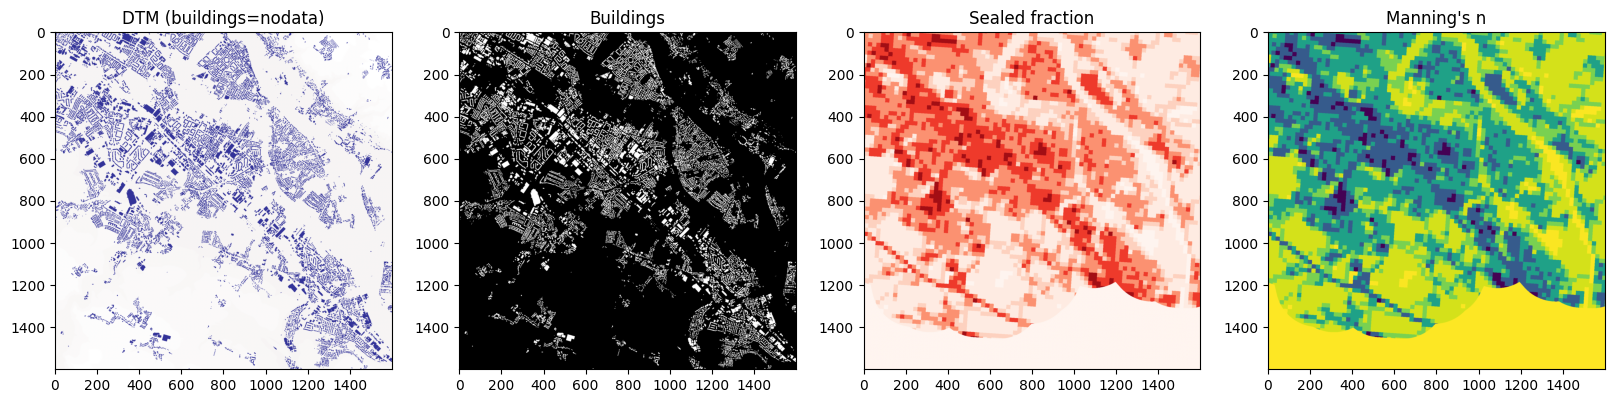

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(dtm, cmap="terrain"); axes[0].set_title("DTM (buildings=nodata)")
axes[1].imshow(building_raster, cmap="gray"); axes[1].set_title("Buildings")
axes[2].imshow(sealed_frac, cmap="Reds", vmin=0, vmax=1); axes[2].set_title("Sealed fraction")
axes[3].imshow(manning_n, cmap="viridis"); axes[3].set_title("Manning's n")
plt.show()

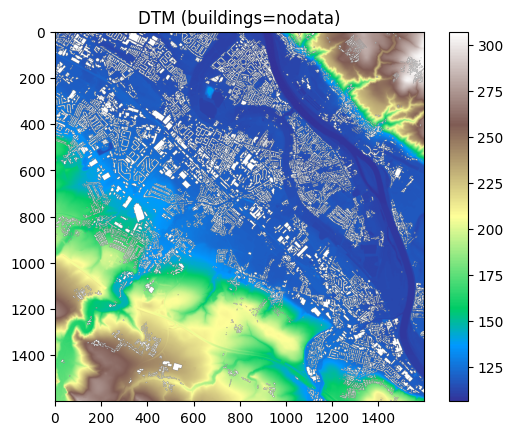

In [14]:
import numpy as np
dtm_masked = np.ma.masked_equal(dtm, profile["nodata"])
plt.imshow(dtm_masked, cmap="terrain")
plt.title("DTM (buildings=nodata)")
plt.colorbar()
plt.show()

In [15]:
n_total = sealed_frac.size
n_exact_zero = np.sum(sealed_frac == 0.0)
print(f"{n_exact_zero} / {n_total} cells = {100*n_exact_zero/n_total:.1f}% have sealed_frac exactly 0.0")

413842 / 2560000 cells = 16.2% have sealed_frac exactly 0.0


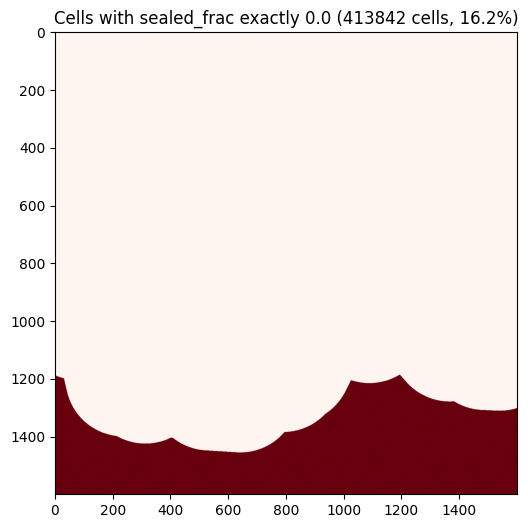

In [16]:
import matplotlib.pyplot as plt

mask = (sealed_frac == 0.0)
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="Reds")
plt.title(f"Cells with sealed_frac exactly 0.0 ({mask.sum()} cells, {100*mask.mean():.1f}%)")
plt.show()

Valid domain: 2146158 / 2560000 cells (83.8%)


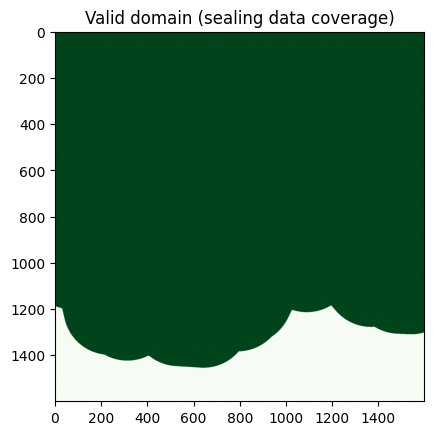

In [17]:
from shapely.ops import unary_union

# Build one polygon = union of all sealing polygons (the data's true footprint)
gdf_sealing = gpd.read_file(SEALING_SHP)
if gdf_sealing.crs.to_string() != profile["crs"]:
    gdf_sealing = gdf_sealing.to_crs(profile["crs"])

sealing_footprint = unary_union(gdf_sealing.geometry)

# Rasterize that footprint onto your 5m grid -> True where sealing data exists
domain_mask = rasterize(
    [(sealing_footprint, 1)],
    out_shape=(profile["height"], profile["width"]),
    transform=profile["transform"],
    fill=0,
    dtype="uint8",
).astype(bool)

print(f"Valid domain: {domain_mask.sum()} / {domain_mask.size} cells "
      f"({100*domain_mask.mean():.1f}%)")

# Quick visual check it matches the gap shape you found
plt.imshow(domain_mask, cmap="Greens")
plt.title("Valid domain (sealing data coverage)")
plt.show()

In [18]:
dem_nodata = profile["nodata"]
sealing_nodata = -9999.0

dtm_clipped = dtm.copy()
dtm_clipped[~domain_mask] = dem_nodata

building_raster_final = building_raster

sealed_frac_clipped = sealed_frac.copy()
sealed_frac_clipped[~domain_mask] = sealing_nodata

nonsealed_frac_clipped = nonsealed_frac.copy()
nonsealed_frac_clipped[~domain_mask] = sealing_nodata

manning_n_clipped = manning_n.copy()
manning_n_clipped[~domain_mask] = sealing_nodata

print("Clipping applied. Valid cells:", domain_mask.sum(),
      "/", domain_mask.size, f"({100*domain_mask.mean():.1f}%)")

Clipping applied. Valid cells: 2146158 / 2560000 (83.8%)


In [19]:
write_raster(f"{OUT_DIR}/dtm.tif", dtm_clipped, profile, nodata=dem_nodata)
write_raster(f"{OUT_DIR}/buildings.tif", building_raster_final, profile, dtype="uint8", nodata=0)
write_raster(f"{OUT_DIR}/sealed_fraction.tif", sealed_frac_clipped, profile, nodata=sealing_nodata)
write_raster(f"{OUT_DIR}/nonsealed_fraction.tif", nonsealed_frac_clipped, profile, nodata=sealing_nodata)
write_raster(f"{OUT_DIR}/manning_n.tif", manning_n_clipped, profile, nodata=sealing_nodata)

print("Re-written clipped rasters to:", OUT_DIR)

Re-written clipped rasters to: /content/drive/MyDrive/flood_forecasting/model_inputs


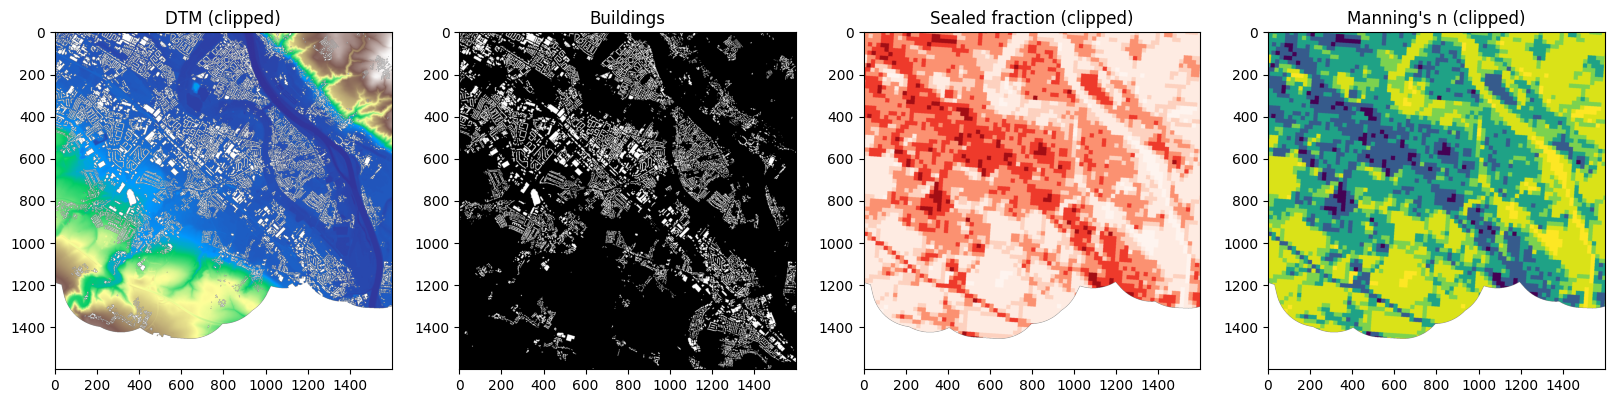

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(np.ma.masked_equal(dtm_clipped, dem_nodata), cmap="terrain")
axes[0].set_title("DTM (clipped)")

axes[1].imshow(building_raster_final, cmap="gray")
axes[1].set_title("Buildings")

axes[2].imshow(np.ma.masked_equal(sealed_frac_clipped, sealing_nodata), cmap="Reds", vmin=0, vmax=1)
axes[2].set_title("Sealed fraction (clipped)")

axes[3].imshow(np.ma.masked_equal(manning_n_clipped, sealing_nodata), cmap="viridis")
axes[3].set_title("Manning's n (clipped)")

plt.show()

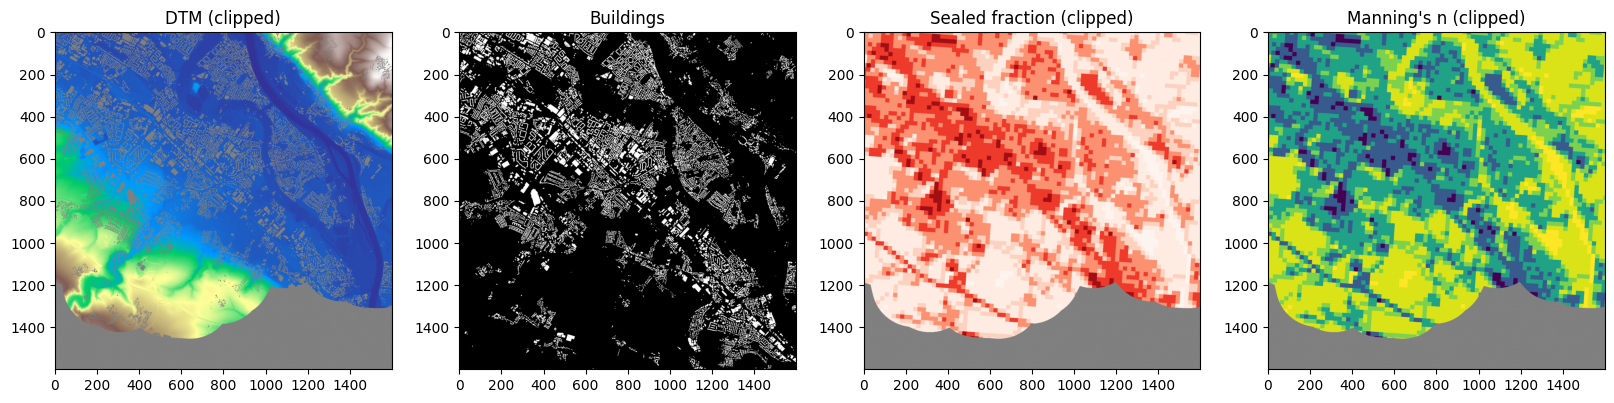

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

cmap_terrain = plt.cm.terrain.copy()
cmap_terrain.set_bad("grey")
cmap_reds = plt.cm.Reds.copy()
cmap_reds.set_bad("grey")
cmap_viridis = plt.cm.viridis.copy()
cmap_viridis.set_bad("grey")

axes[0].imshow(np.ma.masked_equal(dtm_clipped, dem_nodata), cmap=cmap_terrain)
axes[0].set_title("DTM (clipped)")

axes[1].imshow(building_raster_final, cmap="gray")
axes[1].set_title("Buildings")

axes[2].imshow(np.ma.masked_equal(sealed_frac_clipped, sealing_nodata), cmap=cmap_reds, vmin=0, vmax=1)
axes[2].set_title("Sealed fraction (clipped)")

axes[3].imshow(np.ma.masked_equal(manning_n_clipped, sealing_nodata), cmap=cmap_viridis)
axes[3].set_title("Manning's n (clipped)")

plt.show()

In [22]:
print("Sealed fraction - unique values:", np.unique(sealed_frac_clipped)[:5], "...")
print("Cells equal to sealing_nodata:", np.sum(sealed_frac_clipped == sealing_nodata))
print("Cells equal to exactly 0.0 (should be ~0 now):", np.sum(sealed_frac_clipped == 0.0))

Sealed fraction - unique values: [-9.999e+03  5.000e-03  5.500e-02  1.750e-01  3.750e-01] ...
Cells equal to sealing_nodata: 413842
Cells equal to exactly 0.0 (should be ~0 now): 0
